# 2021 vs 2022 Growth & Scale Analysis
**Objective:** Quantify the scale shift between 2021 and 2022 to understand the 'Bias' in our current models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.config import Config

sales = pd.read_parquet(Config.PROCESSED_DATA_DIR / "sales.parquet")
sales['Date'] = pd.to_datetime(sales['Date'])

# Calculate Yearly Stats
yearly_stats = sales.groupby(sales['Date'].dt.year)[['Revenue', 'COGS']].sum()
print("Yearly Totals:")
print(yearly_stats.tail(5))

growth_21_22_rev = (yearly_stats.loc[2022, 'Revenue'] / yearly_stats.loc[2021, 'Revenue'] - 1) * 100
growth_21_22_cogs = (yearly_stats.loc[2022, 'COGS'] / yearly_stats.loc[2021, 'COGS'] - 1) * 100

print(f"\nGrowth 2021 -> 2022 (Revenue): {growth_21_22_rev:.2f}%")
print(f"Growth 2021 -> 2022 (COGS): {growth_21_22_cogs:.2f}%")

Yearly Totals:
           Revenue          COGS
Date                            
2018  1.850122e+09  1.542176e+09
2019  1.136801e+09  1.005203e+09
2020  1.054512e+09  8.860851e+08
2021  1.043040e+09  9.411301e+08
2022  1.169749e+09  1.020420e+09

Growth 2021 -> 2022 (Revenue): 12.15%
Growth 2021 -> 2022 (COGS): 8.42%


## Visualizing the Scale Shift

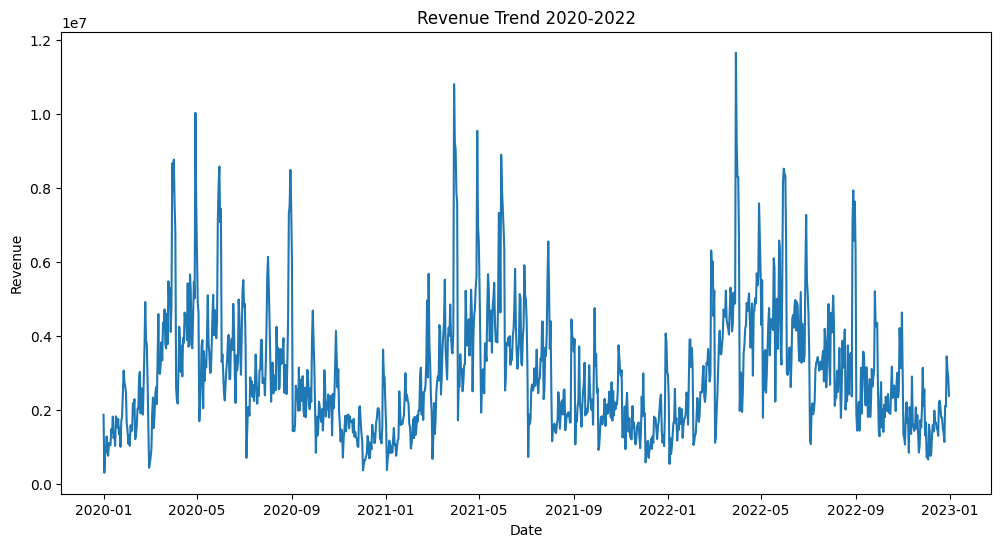

In [2]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=sales[sales['Date'].dt.year >= 2020], x='Date', y='Revenue')
plt.title("Revenue Trend 2020-2022")
plt.show()